<a href="https://colab.research.google.com/github/sumitkharayat/Machine-learning-work/blob/main/Anomaly%20Detection%20(e.g.%2C%20credit%20card%20fraud%2C%20network%20intrusions).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Anomaly Detection

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

Load Data set

In [ ]:

df = pd.read_csv("/content/drive/MyDrive/Applied ML lab/Exp-5,6,7,8 Data and Question-20260301/anomaly_detection_dataset_500_samples.csv")

print(df.head())
print(df.shape)


   Feature_1  Feature_2  Anomaly_Label
0  43.259073  53.716320              0
1  43.815246  43.397717              0
2  46.942411  42.966695              0
3  48.911594  55.493884              0
4  52.575238  69.263657              0
(500, 3)


In [ ]:
def preprocess_data(df):
    df = df.dropna()

    # Separate features and target
    if 'Anomaly_Label' in df.columns:
        y = df['Anomaly_Label']
        X = df.drop('Anomaly_Label', axis=1)
    else:
        y = None
        X = df

    return X, y

In [ ]:
def scale_features(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

In [ ]:
def get_models():
    return {
        "Isolation Forest": IsolationForest(contamination=0.1, random_state=42),
        "Local Outlier Factor": LocalOutlierFactor(n_neighbors=20, contamination=0.1),
        "One-Class SVM": OneClassSVM(nu=0.1)
    }

In [ ]:

def evaluate_models(predictions, y_true):
    results = {}

    for name, y_pred in predictions.items():
        if y_true is not None:
            acc = accuracy_score(y_true, y_pred)
            results[name] = acc

            print(f"\n{name}")
            print("Accuracy:", acc)
            print("Classification Report:\n", classification_report(y_true, y_pred))

    return results

In [ ]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix - " + model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



Isolation Forest
Accuracy: 0.96
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98       470
           1       0.60      1.00      0.75        30

    accuracy                           0.96       500
   macro avg       0.80      0.98      0.86       500
weighted avg       0.98      0.96      0.96       500


Local Outlier Factor
Accuracy: 0.844
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.90      0.92       470
           1       0.02      0.03      0.03        30

    accuracy                           0.84       500
   macro avg       0.48      0.46      0.47       500
weighted avg       0.88      0.84      0.86       500


One-Class SVM
Accuracy: 0.904
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.93      0.95       470
           1       0.32      0.53      0.40        30

    accu

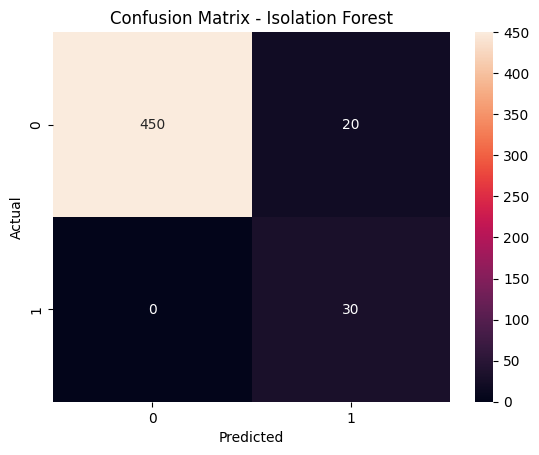

In [ ]:
def load_data(file_path):
    return pd.read_csv(file_path)

def main():
    df = load_data("/content/drive/MyDrive/Applied ML lab/Exp-5,6,7,8 Data and Question-20260301/anomaly_detection_dataset_500_samples.csv")

    X, y = preprocess_data(df)

    X_scaled = scale_features(X)

    models = get_models()

    predictions = train_and_predict(models, X_scaled)

    # Evaluate (only if labels exist)
    results = evaluate_models(predictions, y)

    # Plot confusion matrix for one model (if labels exist)
    if y is not None:
        best_model = max(results, key=results.get)
        plot_confusion_matrix(y, predictions[best_model], best_model)


if __name__ == "__main__":
    main()